## Bathymetry data generation

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

In [64]:
df_read = pd.read_csv(
    "histogram_Aral_Sea_64m_UTM_0.csv",
    sep=";",          # delimiter 
    header=0,         # row number for column names
    decimal=",",       # decimal point character
    index_col=None,   # or a column name / index
    na_values=["NA", ""],  # treat these as NaN
)

df_delta = df_read[(df_read["Elevation"] < 65) & (df_read["Elevation"] >= -13)].copy()

df = df_read[(df_read["Elevation"] < 65) & (df_read["Elevation"] >= 11)].copy()


In [65]:
df_read_copy = pd.read_csv(
    "histogram_Aral_Sea_64m_UTM_copy_0.csv",
    sep=";",          # delimiter 
    header=0,         # row number for column names
    decimal=",",       # decimal point character
    index_col=None,   # or a column name / index
    na_values=["NA", ""],  # treat these as NaN
)

df_copy = df_read_copy[(df_read["Elevation"] < 65)].copy()
#df_copy = df_read_copy.copy()

/tmp/ipykernel_140393/791790786.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_copy = df_read_copy[(df_read["Elevation"] < 65)].copy()


In [66]:
df_read_table = pd.read_csv(
    "Aral_Tabel.csv",
    sep=";",          # delimiter 
    header=0,         # row number for column names
    decimal=".",       # decimal point character
    index_col=None,   # or a column name / index
    na_values=["NA", ""],  # treat these as NaN
)


df_obs = df_read_table.copy()
df_obs["Elevation"] = df_obs['elevation']#-17
#df = df_read[(df_read["Elevation"] < 65) & (df_read["Elevation"] >= 10)].copy(
df_obs.head()

,Year,Amudarya_Q,Amudarya_s,Syrdarya_Q,Syrdarya_s,Precipitation,Evaporation,elevation,Volume,Area,Salinity,Elevation
0,1950,41.0,0.47,11.9,0.57,9.22,66.06,52.82,1060.17,65273,10.17,52.82
1,1951,33.4,0.52,13.2,0.65,8.07,59.19,52.72,1054.14,64896,9.74,52.72
2,1952,55.2,0.41,18.8,0.58,8.78,62.62,52.70,1052.93,64822,10.67,52.70
3,1953,54.8,0.41,19.5,0.68,9.63,64.11,52.86,1063.12,65440,9.82,52.86
4,1954,55.1,0.41,21.1,0.64,10.87,62.87,53.12,1081.91,66649,10.21,53.12


In [67]:
df.tail()

,Area,Elevation
73,1.014236e+11,60.0
74,1.046918e+11,61.0
75,1.081077e+11,62.0
76,1.112685e+11,63.0
77,1.144057e+11,64.0


In [68]:
df['Area_km'] = df['Area']/1e6
df['Area_km'] = df['Area_km'].round(2)
df['Elevation'] = df['Elevation'] + 17

df['delta_volume'] =   df['Area_km'] * 0.001
df["total_volume"] = df["delta_volume"].cumsum()


df_delta['Area_km'] = df_delta['Area']/1e6
df_delta['Area_km'] = df_delta['Area_km'].round(2)
df_delta["delta_area"] = df_delta["Area_km"].diff().fillna(0)

In [69]:
df_copy['Area_km'] = df_copy['Area']/1e6
df_copy['Area_km'] = df_copy['Area_km'].round(2)
df_copy['Elevation'] = df_copy['Elevation']+1

df_copy['delta_volume'] =   df_copy['Area_km'] * 0.001
df_copy["total_volume"] = df_copy["delta_volume"].cumsum()

df_copy['Area2'] = df_copy['Area_km']-5000


In [70]:
df_copy.head()

,Area,Elevation,Area_km,delta_volume,total_volume,Area2
0,1.589717e+05,19.0,0.16,0.00016,0.00016,-4999.84
1,1.589717e+05,20.0,0.16,0.00016,0.00032,-4999.84
2,1.430746e+06,21.0,1.43,0.00143,0.00175,-4998.57
3,3.338406e+06,22.0,3.34,0.00334,0.00509,-4996.66
4,7.471671e+06,23.0,7.47,0.00747,0.01256,-4992.53


Text(0.5, 1.0, 'Elevation - Volume')

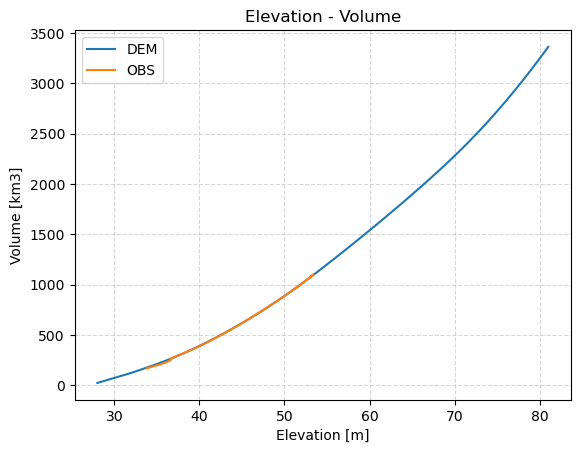

In [71]:
plt.plot(df['Elevation'],df['total_volume'], label='DEM')
plt.plot(df_obs['Elevation'],df_obs['Volume'], label = "OBS")
plt.grid(linestyle='--',alpha = 0.5)
plt.xlabel('Elevation [m]')
plt.ylabel('Volume [km3]')
plt.legend()
plt.title("Elevation - Volume")

Text(0.5, 1.0, 'Elevation - Area')

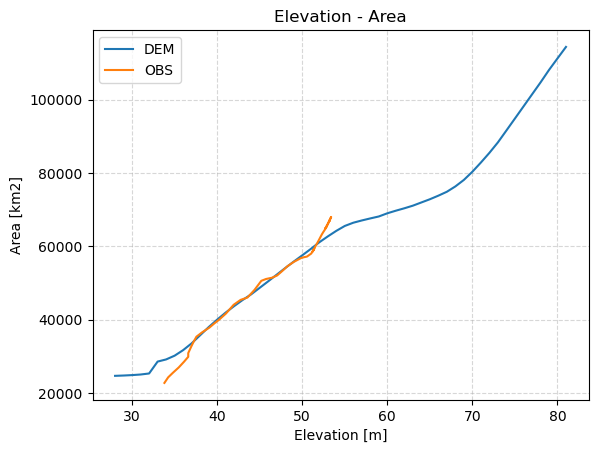

In [72]:
plt.plot(df['Elevation'],df['Area_km'], label = "DEM")
plt.plot(df_obs['Elevation'],df_obs['Area'], label = "OBS")
plt.grid(linestyle='--',alpha = 0.5)
plt.xlabel('Elevation [m]')
plt.ylabel('Area [km2]')
plt.legend()
plt.title("Elevation - Area")

Text(0.5, 1.0, 'Volume - Area')

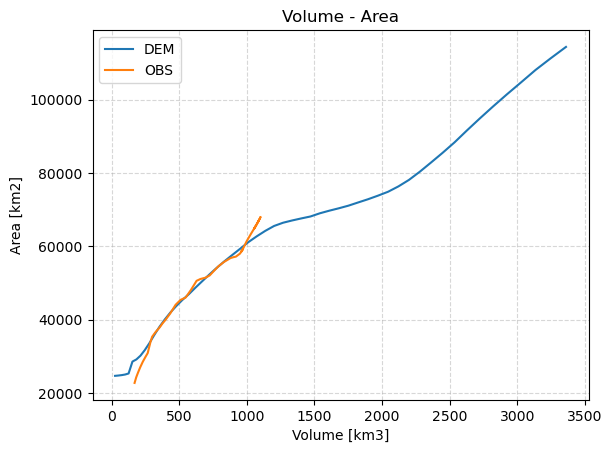

In [73]:
plt.plot(df['total_volume'],df['Area_km'],label="DEM")
plt.plot(df_obs['Volume'],df_obs['Area'], label="OBS")

plt.grid(linestyle='--',alpha = 0.5)
plt.xlabel('Volume [km3]')
plt.ylabel('Area [km2]')
plt.legend()
plt.title("Volume - Area")

Text(0.5, 1.0, 'Increase in Area')

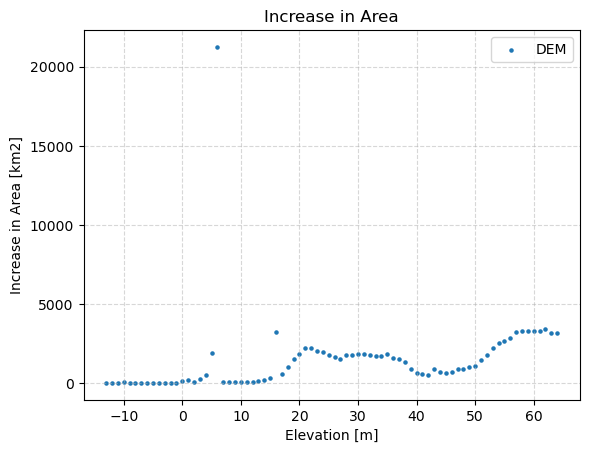

In [74]:
plt.scatter(df_delta['Elevation'],df_delta['delta_area'], label = 'DEM', s=5)

plt.grid(linestyle='--',alpha = 0.5)
plt.xlabel('Elevation [m]')
plt.ylabel('Increase in Area [km2]')
plt.legend(loc = 'best')
plt.title("Increase in Area")



In [75]:
df_obs.head()


,Year,Amudarya_Q,Amudarya_s,Syrdarya_Q,Syrdarya_s,Precipitation,Evaporation,elevation,Volume,Area,Salinity,Elevation
0,1950,41.0,0.47,11.9,0.57,9.22,66.06,52.82,1060.17,65273,10.17,52.82
1,1951,33.4,0.52,13.2,0.65,8.07,59.19,52.72,1054.14,64896,9.74,52.72
2,1952,55.2,0.41,18.8,0.58,8.78,62.62,52.70,1052.93,64822,10.67,52.70
3,1953,54.8,0.41,19.5,0.68,9.63,64.11,52.86,1063.12,65440,9.82,52.86
4,1954,55.1,0.41,21.1,0.64,10.87,62.87,53.12,1081.91,66649,10.21,53.12


In [76]:
df_c = pd.read_csv(
    "Bathymetry_Creteaux.txt",
    sep="\t",      
    decimal=",",   
)

print(df_c.head())

     H      v      s
0  0.0  953.3  57342
1  0.5  925.1  55810
2  1.0  897.5  54695
3  1.5  870.4  53754
4  2.0  843.7  52986


In [77]:
df_copy.head()


,Area,Elevation,Area_km,delta_volume,total_volume,Area2
0,1.589717e+05,19.0,0.16,0.00016,0.00016,-4999.84
1,1.589717e+05,20.0,0.16,0.00016,0.00032,-4999.84
2,1.430746e+06,21.0,1.43,0.00143,0.00175,-4998.57
3,3.338406e+06,22.0,3.34,0.00334,0.00509,-4996.66
4,7.471671e+06,23.0,7.47,0.00747,0.01256,-4992.53


(0.0, 80000.0)

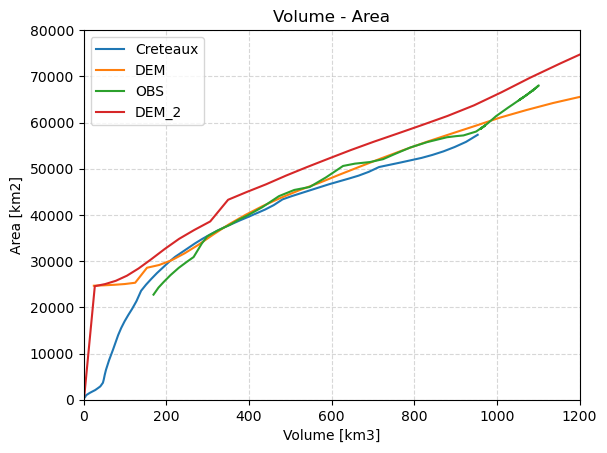

In [83]:
plt.plot(df_c['v'],df_c['s'], label= 'Creteaux')
plt.plot(df['total_volume'],df['Area_km'],label="DEM")
plt.plot(df_obs['Volume'],df_obs['Area'], label="OBS")
plt.plot(df_copy['total_volume'],df_copy['Area_km'],label="DEM_2")
plt.grid(linestyle='--',alpha = 0.5)
plt.xlabel('Volume [km3]')
plt.ylabel('Area [km2]')
plt.legend()
plt.title("Volume - Area")
plt.xlim(0,1200)
plt.ylim(0,80000)

In [79]:
df_c.head()

,H,v,s
0,0.0,953.3,57342
1,0.5,925.1,55810
2,1.0,897.5,54695
3,1.5,870.4,53754
4,2.0,843.7,52986


In [80]:
df_c['Elevation']=53-df_c['H']

Text(0.5, 1.0, 'Elevation - Volume')

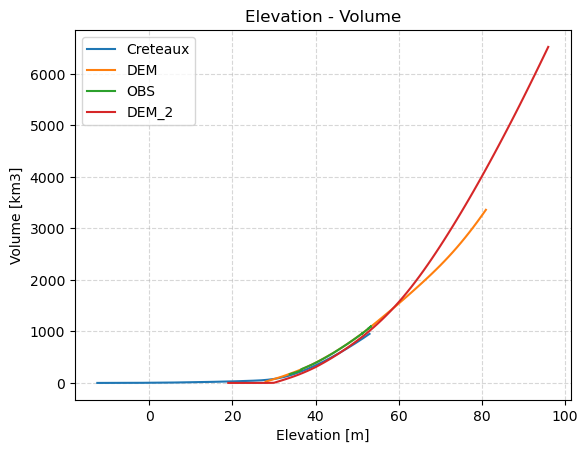

In [88]:
plt.plot(df_c['Elevation'],df_c['v'], label = 'Creteaux')
plt.plot(df['Elevation'],df['total_volume'], label='DEM')
plt.plot(df_obs['Elevation'],df_obs['Volume'], label = "OBS")
plt.plot(df_copy['Elevation'],df_copy['total_volume'], label='DEM_2')
plt.grid(linestyle='--',alpha = 0.5)
plt.xlabel('Elevation [m]')
plt.ylabel('Volume [km3]')
plt.legend()
plt.title("Elevation - Volume")


Text(0.5, 1.0, 'Elevation - Area')

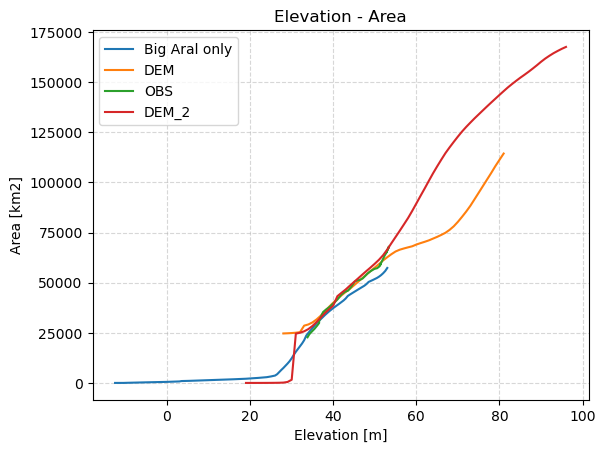

In [89]:
plt.plot(df_c['Elevation'],df_c['s'], label = 'Big Aral only')
plt.plot(df['Elevation'],df['Area_km'], label = "DEM")
plt.plot(df_obs['Elevation'],df_obs['Area'], label = "OBS")
plt.plot(df_copy['Elevation'],df_copy['Area_km'], label = 'DEM_2')
plt.grid(linestyle='--',alpha = 0.5)
plt.xlabel('Elevation [m]')
plt.ylabel('Area [km2]')
plt.legend()
plt.title("Elevation - Area")
# plt.xlim(40,60)
# plt.ylim(40000,75000)